In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

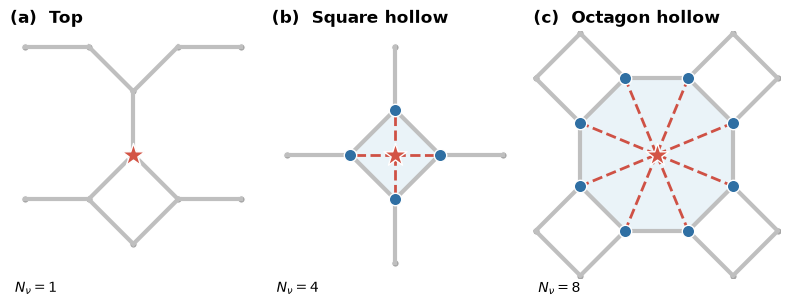

In [4]:
sqrt2 = np.sqrt(2)
a = 1 + sqrt2

basis = {
    "A": np.array([0.0,  1 / sqrt2]),
    "B": np.array([-1 / sqrt2, 0.0]),
    "C": np.array([0.0, -1 / sqrt2]),
    "D": np.array([1 / sqrt2, 0.0]),
}


def position(ix, iy, sub):
    return np.array([ix * a, iy * a]) + basis[sub]


L = 4
sites = {}
bonds = []

for ix in range(-L, L + 1):
    for iy in range(-L, L + 1):

        for sub in ["A", "B", "C", "D"]:
            sites[(ix, iy, sub)] = position(ix, iy, sub)

        # Square bonds
        for s1, s2 in [("A", "B"), ("B", "C"), ("C", "D"), ("D", "A")]:
            bonds.append(((ix, iy, s1), (ix, iy, s2)))

        # Bonds connecting neighboring squares
        bonds.append(((ix, iy, "D"), (ix + 1, iy, "B")))
        bonds.append(((ix, iy, "A"), (ix, iy + 1, "C")))


# Adsorption geometries
top = [(0, 0, "A")]

square = [
    (0, 0, "A"),
    (0, 0, "B"),
    (0, 0, "C"),
    (0, 0, "D"),
]

octagon = [
    (0, 0, "D"),
    (1, 0, "B"),
    (1, 0, "A"),
    (1, 1, "C"),
    (1, 1, "B"),
    (0, 1, "D"),
    (0, 1, "C"),
    (0, 0, "A"),
]


# Plotting
def draw_panel(ax, center, cluster, title, N, fill=True):

    window = 1.95

    # Host bonds
    for site1, site2 in bonds:
        if site1 in sites and site2 in sites:

            p1 = sites[site1] - center
            p2 = sites[site2] - center

            if np.max(np.abs(p1)) < window + 0.4 and \
               np.max(np.abs(p2)) < window + 0.4:

                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    color="0.75",
                    lw=3
                )

    # Host sites
    xy = np.array([
        pos - center
        for pos in sites.values()
        if np.all(np.abs(pos - center) < window)
    ])

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=30,
        color="0.65",
        edgecolor="white"
    )

    # Coupled sites
    cluster_xy = np.array([
        sites[site] - center
        for site in cluster
    ])

    # Highlight hollow plaquette
    if fill:
        ax.add_patch(
            Polygon(
                cluster_xy,
                closed=True,
                facecolor="#D7E8F2",
                edgecolor="#2F6FA3",
                alpha=0.5
            )
        )

    # Hybridization
    for p in cluster_xy:
        ax.plot(
            [0, p[0]],
            [0, p[1]],
            "--",
            color="#CF5145",
            lw=2
        )

    ax.scatter(
        cluster_xy[:, 0],
        cluster_xy[:, 1],
        s=80,
        color="#2F6FA3",
        edgecolor="white",
        zorder=3
    )

    # Adatom
    ax.scatter(
        0,
        0,
        marker="*",
        s=300,
        color="#D35445",
        edgecolor="white",
        zorder=4
    )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.text(
        0.02,
        -0.06,
        rf"$N_\nu={N}$",
        transform=ax.transAxes,
        fontweight="bold"
    )

    ax.set_xlim(-window, window)
    ax.set_ylim(-window, window)
    ax.set_aspect("equal")
    ax.axis("off")


# Figure
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

draw_panel(
    axes[0],
    sites[(0, 0, "A")],
    top,
    "(a)  Top",
    1,
    fill=False
)

draw_panel(
    axes[1],
    np.array([0.0, 0.0]),
    square,
    "(b)  Square hollow",
    4
)

draw_panel(
    axes[2],
    np.array([a / 2, a / 2]),
    octagon,
    "(c)  Octagon hollow",
    8
)

plt.tight_layout()

# plt.savefig(
#     "figures/adsorption_geometries.pdf",
#     bbox_inches="tight"
# )

plt.show()